# Supplier Risk — EDA 01, somente TRAIN

Análise descritiva da base **pré-imputação**. Unidade: fornecedor. São esperados **16.894 fornecedores e 10 features**.
A coluna persistida `risk_level` corresponde a `Risk_Level` da fonte; 0/1 seguem a convenção do projeto, cuja regra de construção não foi comprovada.

**Fronteira:** selecionar `split == "train"` antes de ler valores de features/targets. Não abrir ML-Ready, VALIDATION ou TEST; não imputar, escalar, excluir outliers, treinar, fazer tuning ou escolher threshold. Os hashes leem bytes para integridade, não estatísticas dos holdouts.

## Reprodução

Usar Python **3.14.3** em ambiente isolado novo, não a antiga `.venv` compartilhada. Instalar `ml/supplier_risk/notebooks/requirements.txt` a partir da raiz e selecionar o kernel desse ambiente. Esse manifesto é opcional para EDA e não altera os requisitos dos pipelines. Executar todas as células, em ordem. Nenhuma célula grava datasets; saídas ficam no notebook.

Gráficos usam valores presentes, sem imputação. Estatísticas são descritivas, sem testes de hipótese, causalidade ou estimativa de desempenho de modelos.


In [1]:
import hashlib
import platform
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")
assert platform.python_version() == "3.14.3", "Selecionar o kernel Python 3.14.3."
assert version("pandas") == "2.3.3", "Instalar os requisitos atuais no kernel escolhido."

PROJECT_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "ml/supplier_risk/scripts/build_ml_dataset.py").is_file()),
    None,
)
assert PROJECT_ROOT is not None, "Executar a partir da raiz do projeto ou de notebooks/."
INPUT_DIR = PROJECT_ROOT / "data/processed/supplier_risk"
INPUTS = {
    "features": INPUT_DIR / "supplier_features_base.parquet",
    "targets": INPUT_DIR / "supplier_targets.parquet",
    "split": INPUT_DIR / "supplier_split_assignments.parquet",
}
FEATURES = [
    "financial_stability_score", "on_time_delivery_rate", "defect_rate",
    "geopolitical_risk_index", "lead_time_days", "alternative_suppliers_available",
    "contract_length_months", "environmental_compliance", "previous_disruptions",
    "supplier_record_count",
]
LABELS = [
    "Estabilidade financeira", "Entrega no prazo", "Taxa de defeitos",
    "Índice geopolítico", "Lead time (dias)", "Fornecedores alternativos",
    "Contrato (meses)", "Compliance ambiental", "Disrupções anteriores",
    "Registros distintos",
]
COLORS = ["#176b87", "#cc6633"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "font.size": 10,
})
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 20)

def file_hash(path):
    with path.open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()

assert all(p.is_file() for p in INPUTS.values()), "Uma das três entradas está ausente."
INPUT_HASHES = {name: file_hash(path) for name, path in INPUTS.items()}
DEPENDENCIES = [
    "pandas", "numpy", "pyarrow", "scikit-learn", "matplotlib",
    "nbformat", "nbclient", "ipykernel",
]
print("Geração UTC:", datetime.now(timezone.utc).isoformat())
print("Python:", platform.python_version())
display(pd.Series({name: version(name) for name in DEPENDENCIES}, name="versão"))
for name, digest in INPUT_HASHES.items():
    print(f"SHA-256 {name}: {digest}")


Geração UTC: 2026-09-16T21:35:44.741752+00:00
Python: 3.14.3


pandas           2.3.3
numpy            2.5.2
pyarrow         25.0.1
scikit-learn     1.9.0
matplotlib      3.10.8
nbformat        5.10.4
nbclient        0.10.4
ipykernel        7.2.0
Name: versão, dtype: object

SHA-256 features: 5febc2b6843b9c0c0ed50ef3786ac74e9e82f5e47c8f8c73e2b6277edcbadea6
SHA-256 targets: 480ed2f33bd9352abb79adc2a1a375982b87daa29e28f8aa1cdd3ede0044f29a
SHA-256 split: 13e8795f34b8b4a7e051b666aae945befe18d1b012aa16044414f975334ffa7e


## 1. Seleção restrita e validações

A leitura de split já usa predicado TRAIN. Features e targets são lidos com filtro nos mesmos IDs; não há leitura analítica dos demais fornecedores.
O schema é verificado sem calcular estatísticas. O join é um-para-um, com reconciliação exata de IDs.
Não recalcular o split nem utilizar a label para decidir quem entra na análise.


In [2]:
EXPECTED_SCHEMAS = {
    "features": ["supplier_id", *FEATURES],
    "targets": ["supplier_id", "risk_level"],
    "split": ["supplier_id", "split"],
}
for name, path in INPUTS.items():
    assert pq.read_schema(path).names == EXPECTED_SCHEMAS[name], f"Schema inesperado: {name}"

train_split = pd.read_parquet(
    INPUTS["split"], columns=["supplier_id", "split"],
    filters=[("split", "==", "train")], engine="pyarrow",
)

def valid_ids(frame, context):
    ids = frame["supplier_id"]
    assert len(frame) > 0, f"{context}: vazio"
    assert ids.notna().all(), f"{context}: ID nulo"
    assert ids.map(lambda value: isinstance(value, str) and bool(value.strip())).all()
    assert ids.is_unique, f"{context}: ID duplicado"
    return set(ids)

train_ids = valid_ids(train_split, "split TRAIN")
assert len(train_ids) == 16_894, "Quantidade de fornecedores TRAIN diferente do contrato."
assert train_split["split"].eq("train").all(), "ID de outro split presente."
train_filter = [("supplier_id", "in", sorted(train_ids))]
features_train = pd.read_parquet(INPUTS["features"], filters=train_filter, engine="pyarrow")
targets_train = pd.read_parquet(INPUTS["targets"], filters=train_filter, engine="pyarrow")
assert valid_ids(features_train, "features TRAIN") == train_ids
assert valid_ids(targets_train, "targets TRAIN") == train_ids
assert targets_train["risk_level"].notna().all()
assert set(targets_train["risk_level"].unique()) == {0, 1}
for feature in FEATURES:
    dtype = features_train[feature].dtype
    assert (pd.api.types.is_numeric_dtype(dtype)
            and not pd.api.types.is_bool_dtype(dtype)
            and not pd.api.types.is_complex_dtype(dtype)), f"Tipo numérico inválido: {feature}"
assert not np.isinf(features_train[FEATURES].to_numpy(dtype=float)).any()

data = (
    features_train.merge(targets_train, on="supplier_id", validate="one_to_one")
    .merge(train_split, on="supplier_id", validate="one_to_one")
    .sort_values("supplier_id").reset_index(drop=True)
)
assert len(data) == 16_894 and data["supplier_id"].is_unique
assert set(data["supplier_id"]) == train_ids
assert data["supplier_id"].isin(train_ids).all() and data["split"].eq("train").all()
X = data[FEATURES].copy()
assert X.shape == (16_894, 10)
assert "supplier_id" not in X and "risk_level" not in X
FRAME_HASH = hashlib.sha256(pd.util.hash_pandas_object(data, index=True).values.tobytes()).hexdigest()
validation_summary = pd.Series({
    "fornecedores TRAIN": len(data), "features": X.shape[1],
    "IDs duplicados": int(data["supplier_id"].duplicated().sum()),
    "IDs fora de TRAIN": int((~data["supplier_id"].isin(train_ids)).sum()),
    "infinitos": int(np.isinf(X.to_numpy(dtype=float)).sum()),
    "células nulas preservadas": int(X.isna().sum().sum()),
    "perfis de features repetidos (não IDs)": int(X.duplicated().sum()),
})
display(validation_summary.to_frame("resultado"))


,resultado
fornecedores TRAIN,16894
features,10
IDs duplicados,0
IDs fora de TRAIN,0
infinitos,0
células nulas preservadas,1022
perfis de features repetidos (não IDs),0


## 2. Distribuição do target

Percentuais usam os fornecedores do TRAIN como denominador. Desbalanceamento próximo de 30/70 não é automaticamente erro e não será corrigido nesta EDA. Não confundir frequência da classe 1 com probabilidade de falha real.


,fornecedores,percentual
risk_level,,
0,5008,29.644
1,11886,70.356


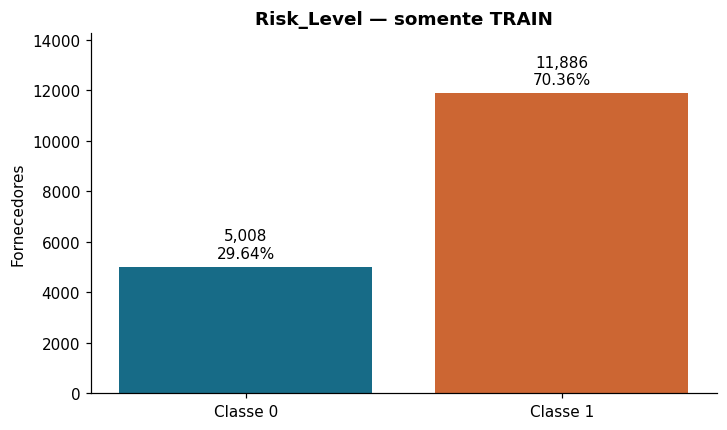

In [3]:
target_distribution = (
    data["risk_level"].value_counts().reindex([0, 1], fill_value=0)
    .rename_axis("risk_level").to_frame("fornecedores")
)
target_distribution["percentual"] = 100 * target_distribution["fornecedores"] / len(data)
display(target_distribution.round(3))
fig, ax = plt.subplots(figsize=(6.5, 3.8), layout="constrained")
bars = ax.bar(["Classe 0", "Classe 1"], target_distribution["fornecedores"], color=COLORS)
ax.bar_label(bars, labels=[
    f"{n:,}\n{pct:.2f}%" for n, pct in target_distribution.itertuples(index=False, name=None)
], padding=4)
ax.set(title="Risk_Level — somente TRAIN", ylabel="Fornecedores")
ax.set_ylim(0, target_distribution["fornecedores"].max() * 1.2)
plt.show()


## 3. Estatísticas e cobertura

`count` considera apenas valores presentes; desvio padrão amostral (`ddof=1`), quartis e mediana ignoram nulos. Valores únicos excluem missing. Não há arredondamento dos dados originais, apenas da apresentação.


In [4]:
feature_stats = pd.DataFrame({
    "dtype": X.dtypes.astype(str), "count": X.count(), "missing": X.isna().sum(),
    "missing_pct": 100 * X.isna().mean(), "mean": X.mean(), "median": X.median(),
    "std": X.std(ddof=1), "min": X.min(), "q1": X.quantile(.25),
    "q3": X.quantile(.75), "max": X.max(), "zeros": X.eq(0).sum(),
    "unique": X.nunique(dropna=True),
})
display(feature_stats.round(4))


,dtype,count,missing,missing_pct,mean,median,std,min,q1,q3,max,zeros,unique
financial_stability_score,float64,16693,201,1.1898,56.6564,56.5768,14.5437,3.1949,46.7772,66.3362,100.000,0,16657
on_time_delivery_rate,float64,16789,105,0.6215,77.5560,77.7036,11.6918,34.1405,69.6102,85.8424,100.000,0,16221
defect_rate,float64,16737,157,0.9293,4.7150,4.5628,3.2081,0.0000,2.2155,6.9087,19.248,1630,15089
geopolitical_risk_index,float64,16894,0,0.0000,33.4210,31.0000,15.4173,11.0000,30.0000,48.0000,87.000,0,17
lead_time_days,float64,16766,128,0.7577,25.6333,25.0000,14.3721,0.0000,15.0000,35.0000,88.000,770,81
alternative_suppliers_available,float64,16751,143,0.8465,2.8583,3.0000,1.8808,0.0000,1.0000,4.0000,10.000,2072,11
contract_length_months,float64,16894,0,0.0000,19.0227,19.0000,11.2824,1.0000,11.0000,27.0000,68.000,0,62
environmental_compliance,float64,16715,179,1.0595,70.9402,71.4000,17.2341,1.5200,59.2550,83.4900,100.950,0,5335
previous_disruptions,float64,16785,109,0.6452,0.9585,1.0000,0.9806,0.0000,0.0000,1.0000,6.000,6452,7
supplier_record_count,int64,16894,0,0.0000,1.0227,1.0000,0.1510,1.0000,1.0000,1.0000,3.000,0,3


## 4. Distribuições e outliers

Variáveis com até 12 valores distintos usam barras; as demais usam histogramas com 30 intervalos de igual largura. As regras são descritivas e não utilizam a label. Nenhum valor é removido ou recortado.
O critério de Tukey (1,5 × IQR) sinaliza extremos estatísticos, **não erros de negócio**. IQR zero torna esse indicador particularmente limitado.


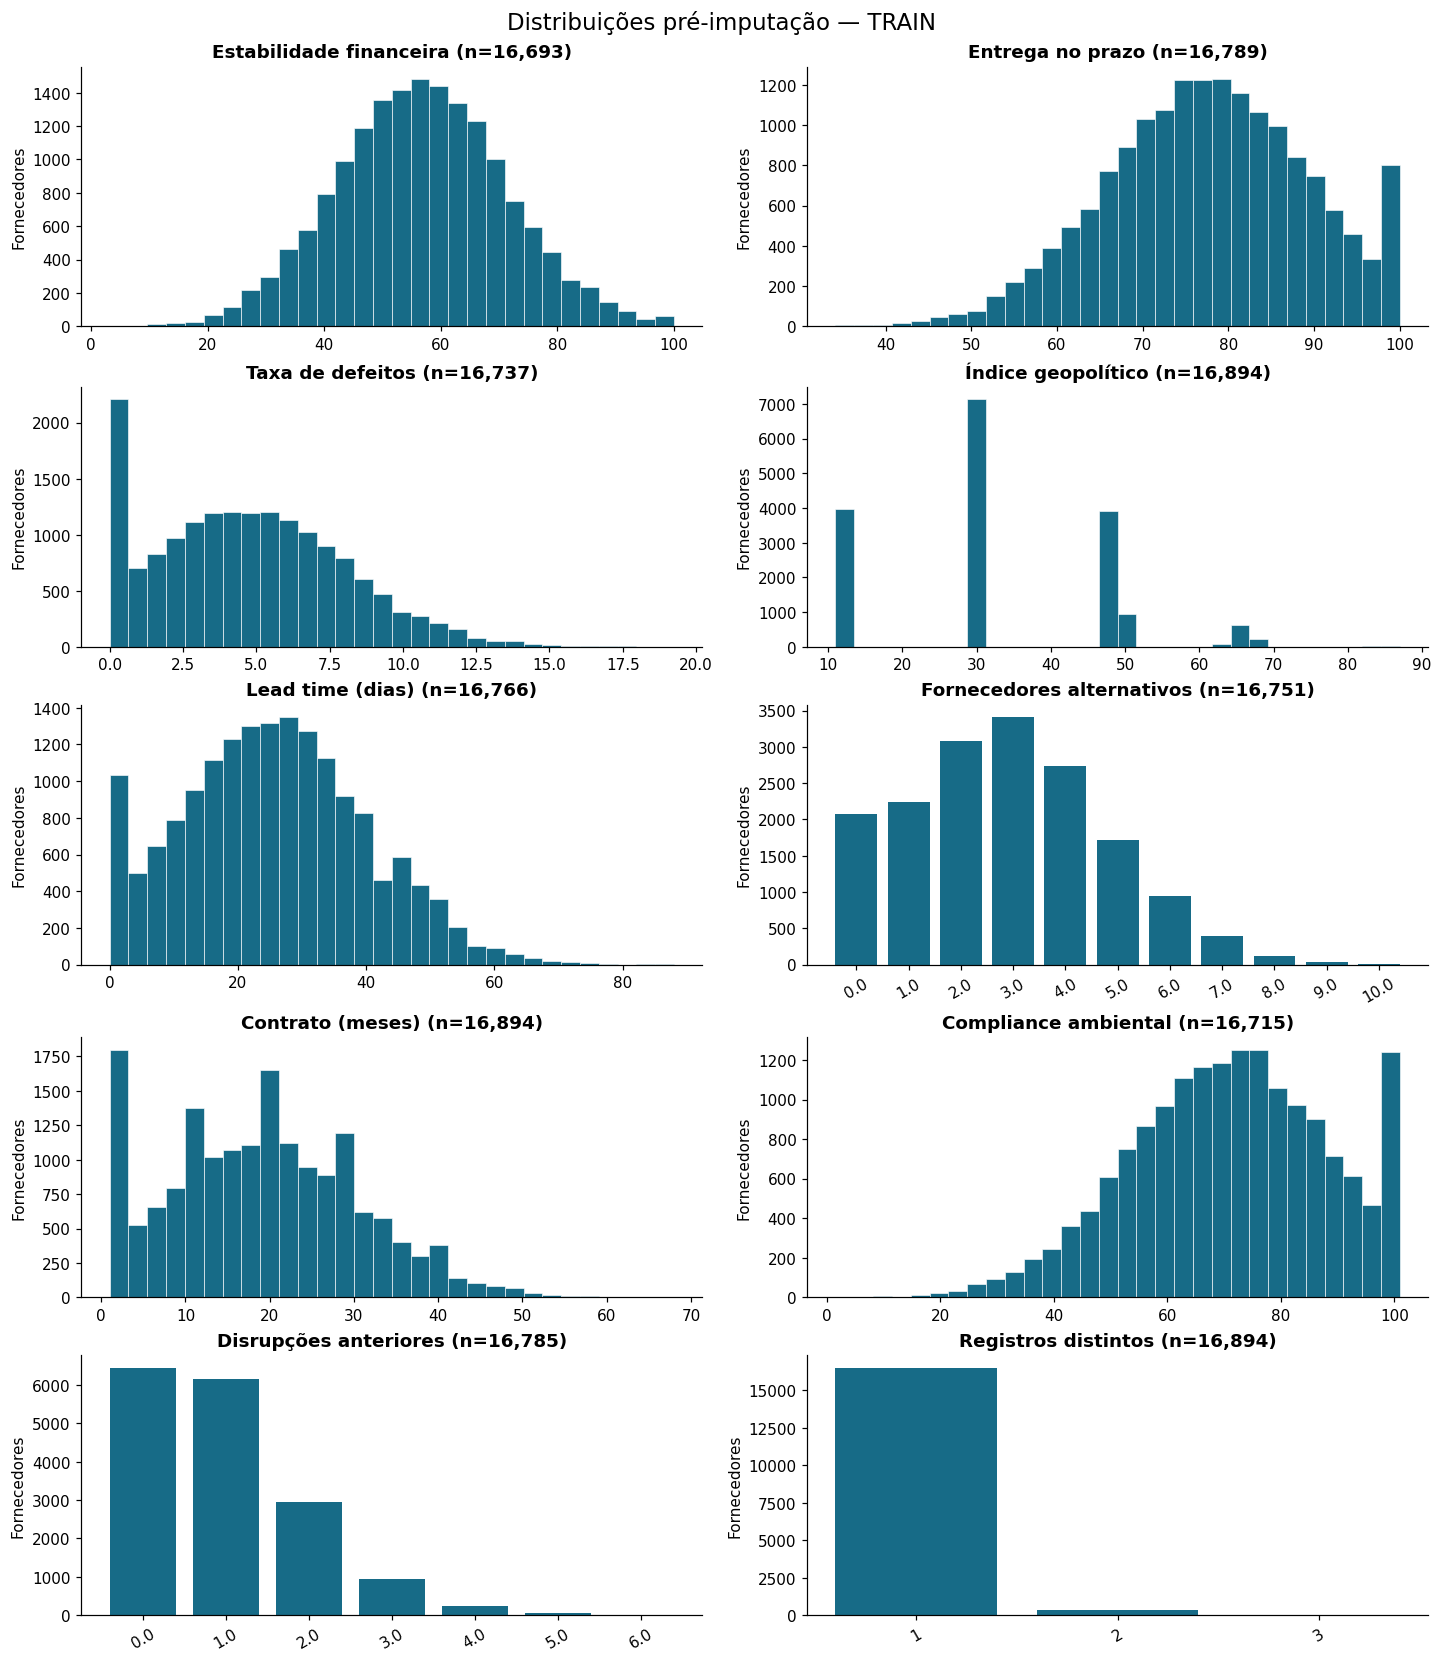

,iqr,limite_inferior,limite_superior,fora_1_5_iqr,pct_dos_presentes,negativos,zeros
financial_stability_score,19.5591,17.4385,95.6749,125,0.7488,0,0
on_time_delivery_rate,16.2322,45.2619,110.1907,62,0.3693,0,0
defect_rate,4.6932,-4.8243,13.9485,70,0.4182,0,1630
geopolitical_risk_index,18.0000,3.0000,75.0000,45,0.2664,0,0
lead_time_days,20.0000,-15.0000,65.0000,67,0.3996,0,770
alternative_suppliers_available,3.0000,-3.5000,8.5000,39,0.2328,0,2072
contract_length_months,16.0000,-13.0000,51.0000,56,0.3315,0,0
environmental_compliance,24.2350,22.9025,119.8425,60,0.3590,0,0
previous_disruptions,1.0000,-1.5000,2.5000,1236,7.3637,0,6452
supplier_record_count,0.0000,1.0000,1.0000,379,2.2434,0,0


In [5]:
fig, axes = plt.subplots(5, 2, figsize=(13, 15), layout="constrained")
for ax, feature, label in zip(axes.flat, FEATURES, LABELS, strict=True):
    present = X[feature].dropna()
    if present.nunique() <= 12:
        frequencies = present.value_counts().sort_index()
        ax.bar(frequencies.index.astype(str), frequencies, color=COLORS[0])
        ax.tick_params(axis="x", rotation=30)
    else:
        ax.hist(present, bins=30, color=COLORS[0], edgecolor="white", linewidth=.4)
    ax.set(title=f"{label} (n={len(present):,})", ylabel="Fornecedores")
fig.suptitle("Distribuições pré-imputação — TRAIN", fontsize=15)
plt.show()

iqr = X.quantile(.75) - X.quantile(.25)
iqr_low = X.quantile(.25) - 1.5 * iqr
iqr_high = X.quantile(.75) + 1.5 * iqr
outside_iqr = X.lt(iqr_low) | X.gt(iqr_high)
outlier_audit = pd.DataFrame({
    "iqr": iqr, "limite_inferior": iqr_low, "limite_superior": iqr_high,
    "fora_1_5_iqr": outside_iqr.sum(),
    "pct_dos_presentes": 100 * outside_iqr.sum() / X.count(),
    "negativos": X.lt(0).sum(), "zeros": X.eq(0).sum(),
})
display(outlier_audit.round(4))


## 5. Diferenças descritivas entre classes

Cada estatística usa os valores presentes daquela feature/classe; o suporte é informado. Diferença relativa assinada = 100 × (média 1 − média 0) / |média 0|, apenas para dias, meses e contagens, se média 0 for diferente de zero. Não atribuir significado de razão a scores cuja escala não foi confirmada.
Os boxplots preservam os extremos. Diferenças não demonstram causalidade, capacidade preditiva fora de TRAIN ou validade empresarial da label.


,count_0,mean_0,median_0,std_0,count_1,mean_1,median_1,std_1,delta_mean_1_minus_0,abs_mean_difference,relative_difference_pct
financial_stability_score,4938.0,68.2487,68.0242,12.2969,11755.0,51.7867,52.0772,12.5179,-16.4620,16.4620,NaN
on_time_delivery_rate,4976.0,78.6215,78.8851,11.6520,11813.0,77.1072,77.1387,11.6800,-1.5142,1.5142,NaN
defect_rate,4965.0,4.6536,4.5586,3.1926,11772.0,4.7409,4.5637,3.2143,0.0873,0.0873,NaN
geopolitical_risk_index,5008.0,24.6464,30.0000,13.0159,11886.0,37.1181,31.0000,14.8447,12.4718,12.4718,NaN
lead_time_days,4962.0,24.4742,24.0000,14.0516,11804.0,26.1206,26.0000,14.4776,1.6463,1.6463,6.7269
alternative_suppliers_available,4966.0,3.4921,3.0000,1.9135,11785.0,2.5912,3.0000,1.8013,-0.9010,0.9010,-25.7999
contract_length_months,5008.0,16.8584,16.0000,10.7835,11886.0,19.9346,20.0000,11.3638,3.0762,3.0762,18.2473
environmental_compliance,4954.0,75.0143,75.6750,16.5024,11761.0,69.2241,69.5500,17.2482,-5.7902,5.7902,NaN
previous_disruptions,4971.0,0.7260,1.0000,0.8550,11814.0,1.0563,1.0000,1.0131,0.3303,0.3303,45.4922
supplier_record_count,5008.0,1.0214,1.0000,0.1460,11886.0,1.0233,1.0000,0.1531,0.0019,0.0019,0.1898


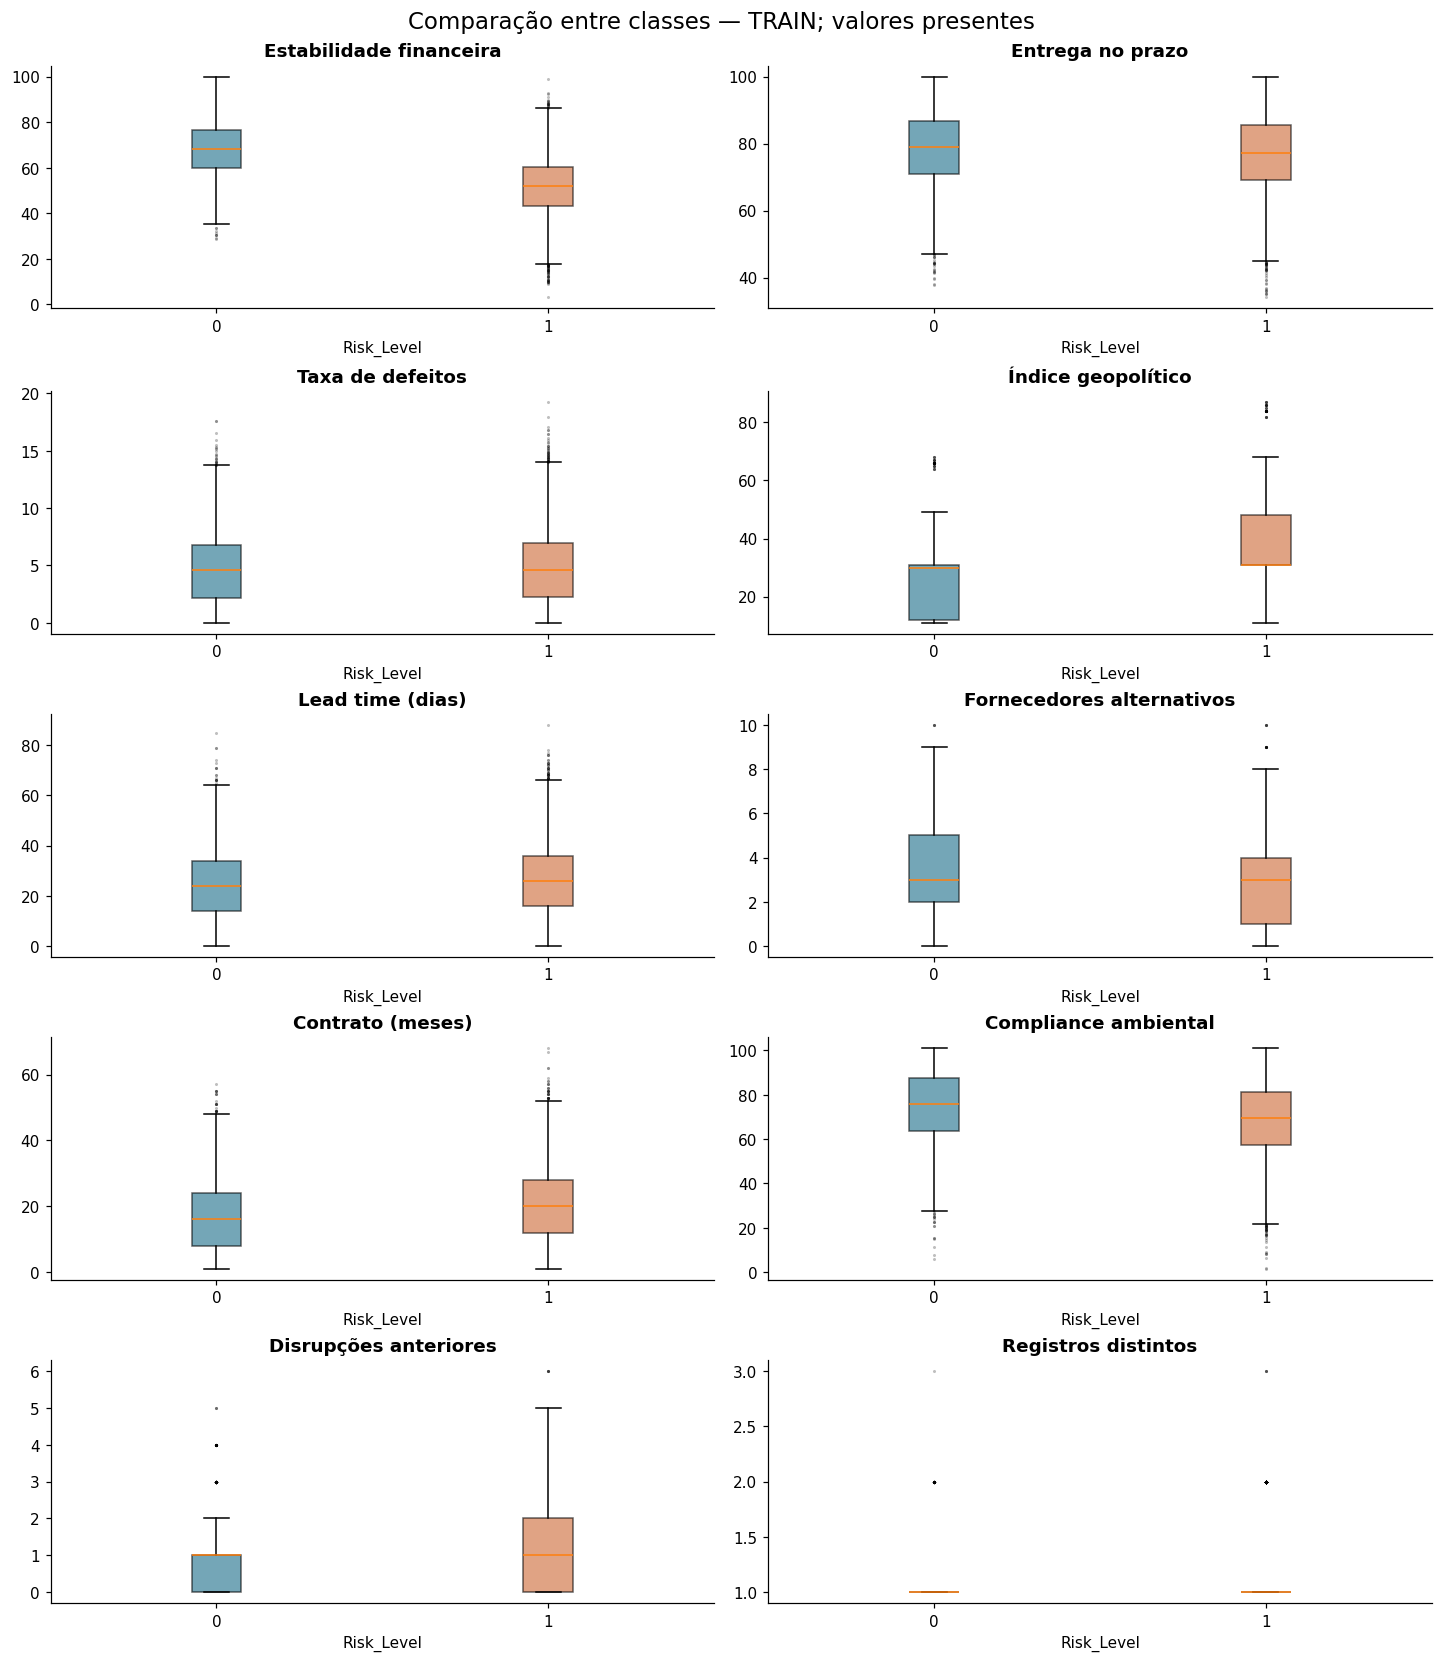

In [6]:
group_stats = data.groupby("risk_level")[FEATURES].agg(["count", "mean", "median", "std"])
class_comparison = pd.DataFrame(index=FEATURES)
for risk in [0, 1]:
    for statistic in ["count", "mean", "median", "std"]:
        class_comparison[f"{statistic}_{risk}"] = group_stats.loc[risk].xs(statistic, level=1)
class_comparison["delta_mean_1_minus_0"] = class_comparison["mean_1"] - class_comparison["mean_0"]
class_comparison["abs_mean_difference"] = class_comparison["delta_mean_1_minus_0"].abs()
class_comparison["relative_difference_pct"] = np.nan
RATIO_FEATURES = [
    "lead_time_days", "alternative_suppliers_available", "contract_length_months",
    "previous_disruptions", "supplier_record_count",
]
for feature in RATIO_FEATURES:
    baseline = class_comparison.at[feature, "mean_0"]
    if baseline != 0 and pd.notna(baseline):
        class_comparison.at[feature, "relative_difference_pct"] = (
            100 * class_comparison.at[feature, "delta_mean_1_minus_0"] / abs(baseline)
        )
display(class_comparison.round(4))

fig, axes = plt.subplots(5, 2, figsize=(13, 15), layout="constrained")
for ax, feature, label in zip(axes.flat, FEATURES, LABELS, strict=True):
    values = [data.loc[data["risk_level"].eq(risk), feature].dropna() for risk in [0, 1]]
    result = ax.boxplot(
        values, tick_labels=["0", "1"], patch_artist=True, showfliers=True,
        flierprops={"marker": ".", "markersize": 2, "alpha": .25},
    )
    for box, color in zip(result["boxes"], COLORS, strict=True):
        box.set_facecolor(color)
        box.set_alpha(.6)
    ax.set(title=label, xlabel="Risk_Level")
fig.suptitle("Comparação entre classes — TRAIN; valores presentes", fontsize=15)
plt.show()


## 6. Correlações e possível redundância

Pearson (linear) e Spearman (monotônica) são calculadas com exclusão **por par**, sem imputação. A matriz de suporte informa quantos fornecedores contribuíram para cada par; mínimo de 30 para calcular correlação. |r| ≥ 0,80 é apenas sinalizador descritivo de correlação alta entre features, não critério de seleção. Ausência de correlação forte não exclui relações não lineares ou interações.


,feature_1,feature_2,pearson,spearman,n_pairs,max_abs_correlation
2,financial_stability_score,geopolitical_risk_index,0.0420,0.0466,16693,0.0466
7,financial_stability_score,previous_disruptions,0.0336,0.0327,16585,0.0336
25,geopolitical_risk_index,alternative_suppliers_available,0.0252,0.0250,16751,0.0252
30,lead_time_days,alternative_suppliers_available,-0.0218,-0.0198,16626,0.0218
5,financial_stability_score,contract_length_months,0.0205,0.0201,16693,0.0205
4,financial_stability_score,alternative_suppliers_available,-0.0141,-0.0199,16551,0.0199
36,alternative_suppliers_available,environmental_compliance,-0.0175,-0.0187,16574,0.0187
16,on_time_delivery_rate,supplier_record_count,-0.0167,-0.0150,16789,0.0167
27,geopolitical_risk_index,environmental_compliance,0.0153,0.0153,16715,0.0153
12,on_time_delivery_rate,alternative_suppliers_available,-0.0150,-0.0150,16647,0.0150


Pares com |correlação| >= 0,80: 0


,feature_1,feature_2,pearson,spearman,n_pairs,max_abs_correlation


,financial_stability_score,on_time_delivery_rate,defect_rate,geopolitical_risk_index,lead_time_days,alternative_suppliers_available,contract_length_months,environmental_compliance,previous_disruptions,supplier_record_count
financial_stability_score,16693,16590,16537,16693,16566,16551,16693,16518,16585,16693
on_time_delivery_rate,16590,16789,16633,16789,16661,16647,16789,16615,16680,16789
defect_rate,16537,16633,16737,16737,16610,16595,16737,16562,16630,16737
geopolitical_risk_index,16693,16789,16737,16894,16766,16751,16894,16715,16785,16894
lead_time_days,16566,16661,16610,16766,16766,16626,16766,16587,16657,16766
alternative_suppliers_available,16551,16647,16595,16751,16626,16751,16751,16574,16643,16751
contract_length_months,16693,16789,16737,16894,16766,16751,16894,16715,16785,16894
environmental_compliance,16518,16615,16562,16715,16587,16574,16715,16715,16607,16715
previous_disruptions,16585,16680,16630,16785,16657,16643,16785,16607,16785,16785
supplier_record_count,16693,16789,16737,16894,16766,16751,16894,16715,16785,16894


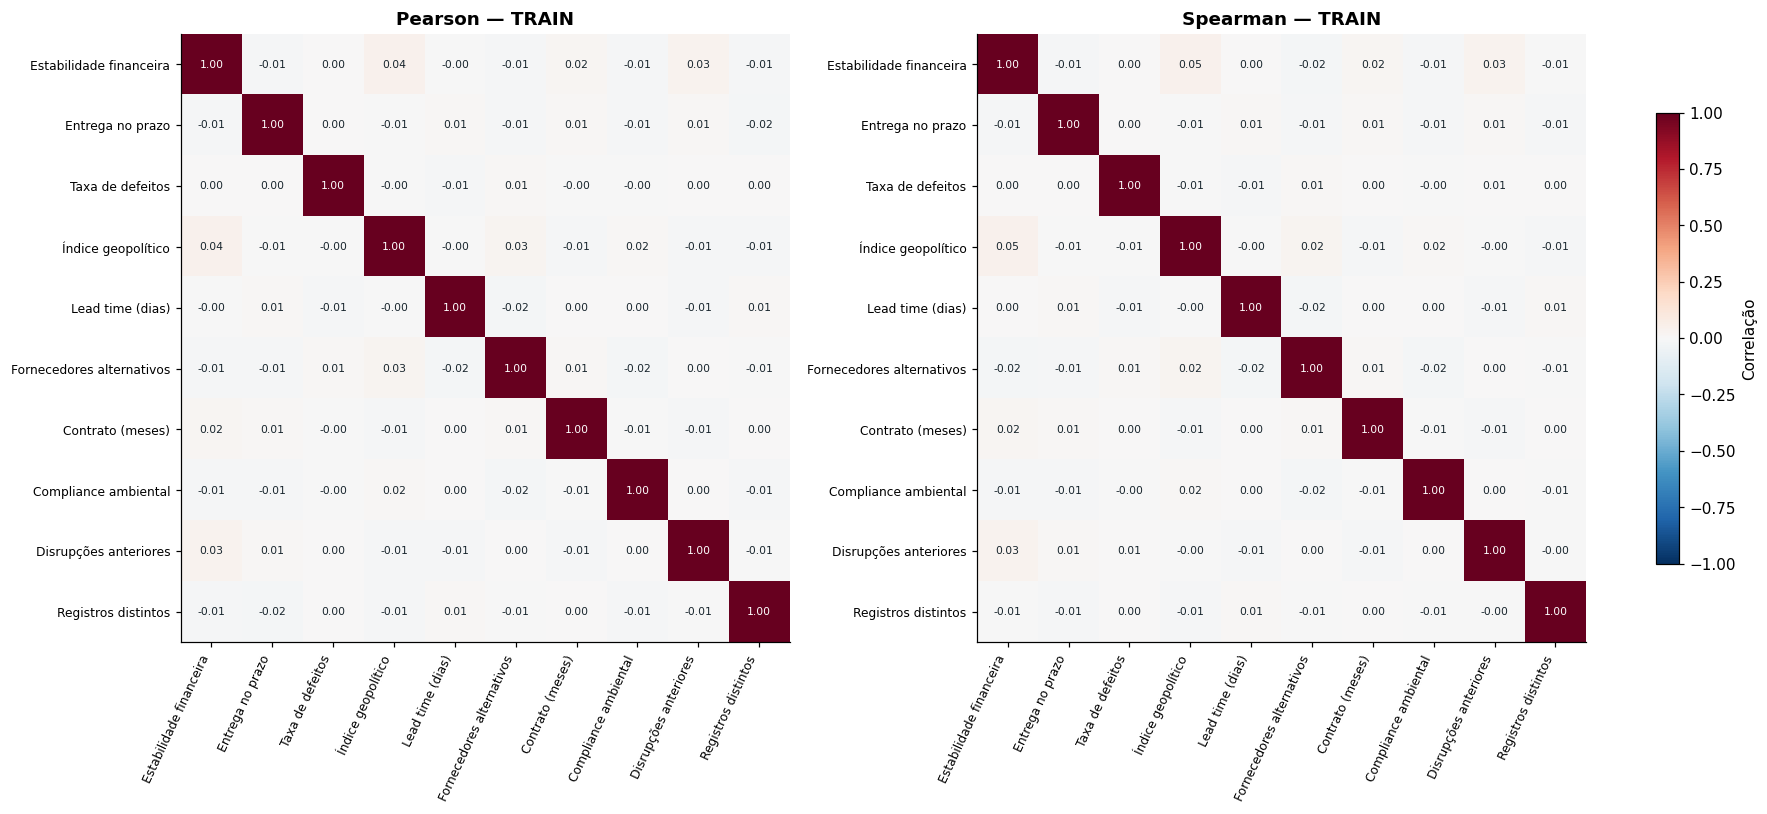

In [7]:
pearson = X.corr(method="pearson", min_periods=30)
spearman = X.corr(method="spearman", min_periods=30)
available = X.notna().astype("int64")
pair_support = available.T @ available
pairs = []
for i, first in enumerate(FEATURES):
    for second in FEATURES[i + 1:]:
        pairs.append({
            "feature_1": first, "feature_2": second,
            "pearson": pearson.at[first, second],
            "spearman": spearman.at[first, second],
            "n_pairs": pair_support.at[first, second],
        })
correlation_pairs = pd.DataFrame(pairs)
correlation_pairs["max_abs_correlation"] = correlation_pairs[["pearson", "spearman"]].abs().max(axis=1)
correlation_pairs = correlation_pairs.sort_values("max_abs_correlation", ascending=False)
display(correlation_pairs.head(10).round(4))
high_correlations = correlation_pairs.loc[correlation_pairs["max_abs_correlation"].ge(.80)]
print("Pares com |correlação| >= 0,80:", len(high_correlations))
display(high_correlations.round(4))
display(pair_support)

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), layout="constrained")
for ax, matrix, name in zip(axes, [pearson, spearman], ["Pearson", "Spearman"], strict=True):
    heatmap = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(10), LABELS, rotation=65, ha="right", fontsize=8)
    ax.set_yticks(range(10), LABELS, fontsize=8)
    ax.set_title(f"{name} — TRAIN")
    for i in range(10):
        for j in range(10):
            ax.text(j, i, f"{matrix.iloc[i, j]:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if abs(matrix.iloc[i, j]) > .6 else "#17242c")
fig.colorbar(heatmap, ax=axes, shrink=.65, label="Correlação")
plt.show()


## 7. Missing e classe

Percentuais das classes são calculados **dentro de cada grupo presente/ausente**, com n explícito. Também se informa a taxa de missing dentro de cada classe.
Grupos pequenos podem gerar percentuais instáveis; associações não demonstram o mecanismo de ausência (MCAR/MAR/MNAR), causalidade ou justificativa para criar uma feature. Os indicadores booleanos abaixo são temporários e **não são adicionados à matriz de features**.


,count,missing,missing_pct
financial_stability_score,16693,201,1.190
on_time_delivery_rate,16789,105,0.622
defect_rate,16737,157,0.929
geopolitical_risk_index,16894,0,0.000
lead_time_days,16766,128,0.758
alternative_suppliers_available,16751,143,0.846
contract_length_months,16894,0,0.000
environmental_compliance,16715,179,1.060
previous_disruptions,16785,109,0.645
supplier_record_count,16894,0,0.000


,feature,estado,n,classe_0,classe_1,classe_0_pct_no_grupo,classe_1_pct_no_grupo
0,financial_stability_score,presente,16693,4938,11755,29.581,70.419
1,financial_stability_score,ausente,201,70,131,34.826,65.174
2,on_time_delivery_rate,presente,16789,4976,11813,29.638,70.362
3,on_time_delivery_rate,ausente,105,32,73,30.476,69.524
4,defect_rate,presente,16737,4965,11772,29.665,70.335
5,defect_rate,ausente,157,43,114,27.389,72.611
6,geopolitical_risk_index,presente,16894,5008,11886,29.644,70.356
7,geopolitical_risk_index,ausente,0,0,0,NaN,NaN
8,lead_time_days,presente,16766,4962,11804,29.596,70.404
9,lead_time_days,ausente,128,46,82,35.938,64.062


,missing_pct_classe_0,missing_pct_classe_1
financial_stability_score,1.398,1.102
on_time_delivery_rate,0.639,0.614
defect_rate,0.859,0.959
geopolitical_risk_index,0.000,0.000
lead_time_days,0.919,0.690
alternative_suppliers_available,0.839,0.850
contract_length_months,0.000,0.000
environmental_compliance,1.078,1.052
previous_disruptions,0.739,0.606
supplier_record_count,0.000,0.000


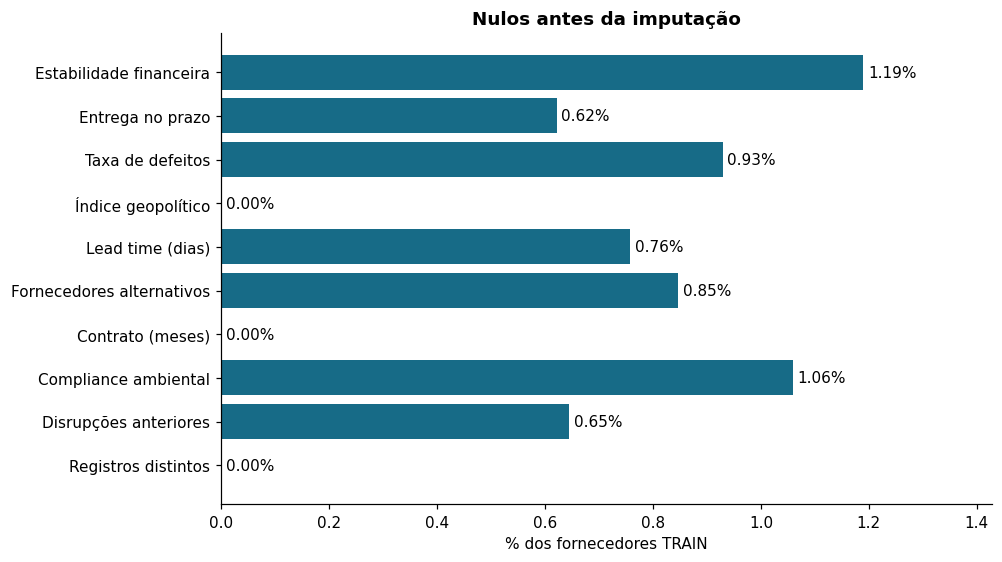

In [8]:
missing_rows = []
for feature in FEATURES:
    for state, mask in [("presente", X[feature].notna()), ("ausente", X[feature].isna())]:
        class_counts = data.loc[mask, "risk_level"].value_counts().reindex([0, 1], fill_value=0)
        n = int(mask.sum())
        missing_rows.append({
            "feature": feature, "estado": state, "n": n,
            "classe_0": int(class_counts[0]), "classe_1": int(class_counts[1]),
            "classe_0_pct_no_grupo": 100 * class_counts[0] / n if n else np.nan,
            "classe_1_pct_no_grupo": 100 * class_counts[1] / n if n else np.nan,
        })
missing_by_target = pd.DataFrame(missing_rows)
missing_rate_by_class = pd.DataFrame({
    f"missing_pct_classe_{risk}": data.loc[data["risk_level"].eq(risk), FEATURES].isna().mean() * 100
    for risk in [0, 1]
})
display(feature_stats[["count", "missing", "missing_pct"]].round(3))
display(missing_by_target.round(3))
display(missing_rate_by_class.round(3))
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
missing_pct = feature_stats["missing_pct"]
bars = ax.barh(LABELS, missing_pct, color=COLORS[0])
ax.bar_label(bars, fmt="%.2f%%", padding=3)
ax.invert_yaxis()
ax.set(xlabel="% dos fornecedores TRAIN", title="Nulos antes da imputação")
ax.set_xlim(0, max(float(missing_pct.max()) * 1.2, 1))
plt.show()


## 8. Investigações obrigatórias

**Compliance > 100:** possível inconsistência de domínio pendente de confirmação da escala original; não aplicar clipping.
**Lead time = 0:** significado ainda não confirmado; não excluir zeros.
Percentuais usam tanto TRAIN total quanto valores presentes; a distribuição por classe usa o conjunto de casos como denominador.


In [9]:
def domain_case(feature, mask):
    values = data.loc[mask, feature]
    counts = data.loc[mask, "risk_level"].value_counts().reindex([0, 1], fill_value=0)
    n = len(values)
    n_present = int(data[feature].notna().sum())
    return pd.Series({
        "n": n, "pct_train": 100 * n / len(data),
        "pct_presentes": 100 * n / n_present if n_present else np.nan,
        "min": values.min(), "max": values.max(),
        "classe_0": int(counts[0]), "classe_1": int(counts[1]),
        "classe_0_pct_casos": 100 * counts[0] / n if n else np.nan,
        "classe_1_pct_casos": 100 * counts[1] / n if n else np.nan,
    })

domain_cases = pd.DataFrame({
    "environmental_compliance > 100": domain_case(
        "environmental_compliance", data["environmental_compliance"].gt(100)
    ),
    "lead_time_days == 0": domain_case("lead_time_days", data["lead_time_days"].eq(0)),
}).T
display(domain_cases.round(4))
print("Valores negativos por feature (registro, não correção):")
display(X.lt(0).sum().to_frame("negativos"))


,n,pct_train,pct_presentes,min,max,classe_0,classe_1,classe_0_pct_casos,classe_1_pct_casos
environmental_compliance > 100,985.0,5.8305,5.8929,100.1,100.95,415.0,570.0,42.1320,57.8680
lead_time_days == 0,770.0,4.5578,4.5926,0.0,0.00,248.0,522.0,32.2078,67.7922


Valores negativos por feature (registro, não correção):


,negativos
financial_stability_score,0
on_time_delivery_rate,0
defect_rate,0
geopolitical_risk_index,0
lead_time_days,0
alternative_suppliers_available,0
contract_length_months,0
environmental_compliance,0
previous_disruptions,0
supplier_record_count,0


### Índice geopolítico e contagem de registros

`geopolitical_risk_index` permanece provisório: procedência, fórmula, data de referência e mapeamento por país não comprovados. Esta EDA não consulta Country nem a fonte alternativa e não resolve essa procedência.
`supplier_record_count` significa registros distintos da fonte após deduplicação, **não histórico temporal**. Pode refletir coleta/completude; os grupos 1/2/3 devem ser lidos com seu suporte.


Cardinalidade geopolítica (sem nulos): 17


,classe_0,classe_1,n,pct_train,classe_1_pct_no_valor
geopolitical_risk_index,,,,,
11.0,609,454,1063,6.2922,42.7093
12.0,1041,783,1824,10.7967,42.9276
13.0,624,450,1074,6.3573,41.8994
30.0,424,1020,1444,8.5474,70.6371
31.0,1666,4026,5692,33.6924,70.7309
48.0,494,3414,3908,23.1325,87.3593
49.0,109,820,929,5.4990,88.2670
64.0,4,60,64,0.3788,93.7500
65.0,5,166,171,1.0122,97.0760


,classe_0,classe_1,n,pct_train,classe_1_pct_no_valor
supplier_record_count,,,,,
1,4902,11613,16515,97.7566,70.3179
2,105,269,374,2.2138,71.9251
3,1,4,5,0.0296,80.0000


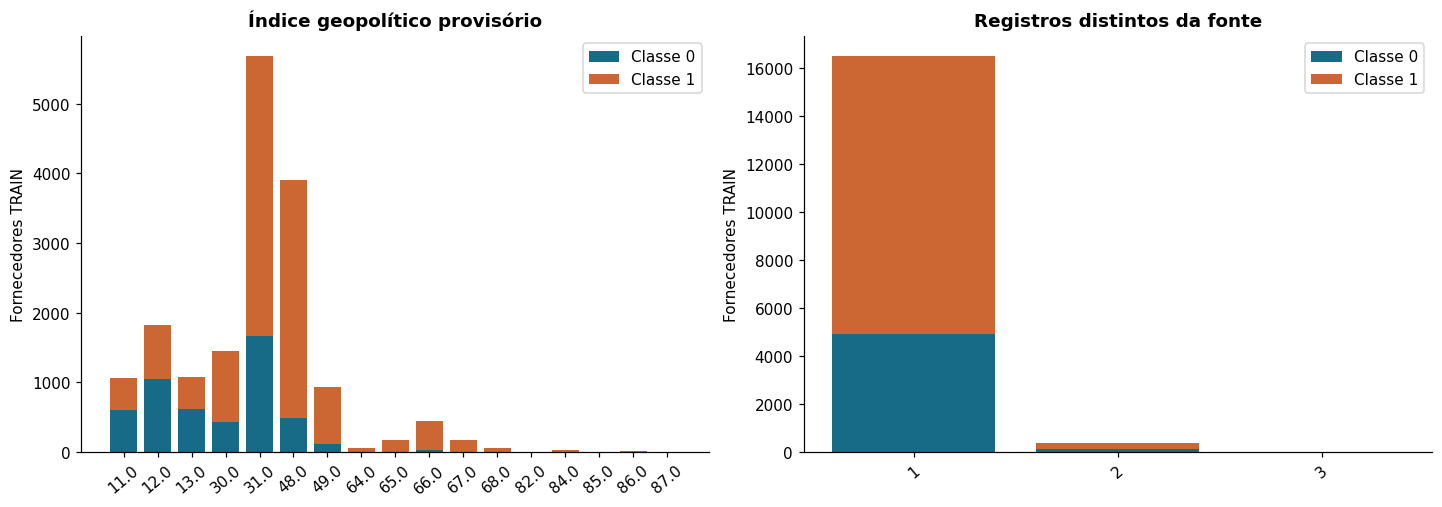

In [10]:
def value_profile(feature):
    counts = pd.crosstab(data[feature], data["risk_level"]).reindex(columns=[0, 1], fill_value=0)
    counts.columns = ["classe_0", "classe_1"]
    counts["n"] = counts[["classe_0", "classe_1"]].sum(axis=1)
    counts["pct_train"] = 100 * counts["n"] / len(data)
    counts["classe_1_pct_no_valor"] = 100 * counts["classe_1"] / counts["n"]
    return counts.sort_index()

geopolitical_profile = value_profile("geopolitical_risk_index")
record_count_profile = value_profile("supplier_record_count")
print("Cardinalidade geopolítica (sem nulos):", X["geopolitical_risk_index"].nunique())
display(geopolitical_profile.round(4))
display(record_count_profile.round(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
for ax, profile, title in zip(
    axes, [geopolitical_profile, record_count_profile],
    ["Índice geopolítico provisório", "Registros distintos da fonte"], strict=True,
):
    positions = np.arange(len(profile))
    ax.bar(positions, profile["classe_0"], label="Classe 0", color=COLORS[0])
    ax.bar(positions, profile["classe_1"], bottom=profile["classe_0"], label="Classe 1", color=COLORS[1])
    ax.set_xticks(positions, profile.index.astype(str), rotation=40)
    ax.set(title=title, ylabel="Fornecedores TRAIN")
    ax.legend()
plt.show()


## 9. Investigação descritiva de possíveis proxies

As análises abaixo **não treinam classificadores, não otimizam cortes e não escolhem threshold**.

- Correlação feature/target (Pearson equivalente à associação ponto-bisserial para target 0/1; Spearman complementar).
- Faixas e quantis por classe; sobreposição dos intervalos observados.
- Até dez faixas por feature: valores exatos quando a cardinalidade é ≤ 10; caso contrário, decis definidos **somente pelos valores da feature**, nunca buscando pureza da label. Empates podem reduzir o número de faixas.
- Percentuais por faixa são frequências amostrais, não probabilidades calibradas. Sempre verificar n e comparar com a prevalência geral da classe 1. Grupos pequenos podem parecer exclusivos por acaso.

Uma eventual separação forte geraria apenas a **hipótese** de uso da feature na construção de Risk_Level. Ausência de separação univariada não descarta regras multivariadas, interações ou vazamento desconhecido.


In [11]:
proxy_associations = pd.DataFrame({
    "n_presentes": X.count(),
    "pearson_target": X.apply(lambda s: s.corr(data["risk_level"], method="pearson")),
    "spearman_target": X.apply(lambda s: s.corr(data["risk_level"], method="spearman")),
})
proxy_associations["max_abs"] = proxy_associations[["pearson_target", "spearman_target"]].abs().max(axis=1)
display(proxy_associations.sort_values("max_abs", ascending=False).round(4))

class_ranges = []
for feature in FEATURES:
    for risk in [0, 1]:
        values = data.loc[data["risk_level"].eq(risk), feature].dropna()
        class_ranges.append({
            "feature": feature, "risk_level": risk, "n": len(values),
            "min": values.min(), "q05": values.quantile(.05), "median": values.median(),
            "q95": values.quantile(.95), "max": values.max(),
        })
class_ranges = pd.DataFrame(class_ranges)
display(class_ranges.round(4))

bands = []
for feature in FEATURES:
    present = data.loc[data[feature].notna(), [feature, "risk_level"]].copy()
    if present[feature].nunique() <= 10:
        present["band"] = present[feature]
    else:
        present["band"] = pd.qcut(present[feature], q=10, labels=False, duplicates="drop")
    grouped = present.groupby("band", observed=True).agg(
        lower=(feature, "min"), upper=(feature, "max"),
        n=("risk_level", "size"), classe_1=("risk_level", "sum"),
    )
    grouped["classe_0"] = grouped["n"] - grouped["classe_1"]
    grouped["classe_1_pct"] = 100 * grouped["classe_1"] / grouped["n"]
    grouped["feature"] = feature
    bands.append(grouped.reset_index(drop=True))
proxy_bands = pd.concat(bands, ignore_index=True)
proxy_bands["largest_class_pct"] = np.maximum(
    proxy_bands["classe_1_pct"], 100 - proxy_bands["classe_1_pct"]
)
display(proxy_bands[[
    "feature", "lower", "upper", "n", "classe_0", "classe_1", "classe_1_pct",
]].round(4))
print("Faixas de maior concentração de uma classe — verificar suporte, não escolher cortes:")
display(proxy_bands.sort_values(["largest_class_pct", "n"], ascending=False).head(15).round(4))
print("Prevalência de referência da classe 1 no TRAIN:", round(100 * data["risk_level"].mean(), 3), "%")


,n_presentes,pearson_target,spearman_target,max_abs
financial_stability_score,16693,-0.5166,-0.5132,0.5166
geopolitical_risk_index,16894,0.3694,0.3619,0.3694
alternative_suppliers_available,16751,-0.2188,-0.2133,0.2188
previous_disruptions,16785,0.1538,0.1549,0.1549
environmental_compliance,16715,-0.1534,-0.1535,0.1535
contract_length_months,16894,0.1245,0.1239,0.1245
on_time_delivery_rate,16789,-0.0591,-0.0603,0.0603
lead_time_days,16766,0.0523,0.0509,0.0523
defect_rate,16737,0.0124,0.0115,0.0124
supplier_record_count,16894,0.0059,0.0056,0.0059


,feature,risk_level,n,min,q05,median,q95,max
0,financial_stability_score,0,4938,28.9368,48.4333,68.0242,89.1424,100.0000
1,financial_stability_score,1,11755,3.1949,30.4767,52.0772,71.6507,98.9847
2,on_time_delivery_rate,0,4976,37.6321,58.6375,78.8851,98.6338,100.0000
3,on_time_delivery_rate,1,11813,34.1405,57.6787,77.1387,97.0428,100.0000
4,defect_rate,0,4965,0.0000,0.0000,4.5586,10.3124,17.5907
5,defect_rate,1,11772,0.0000,0.0000,4.5637,10.3757,19.2480
6,geopolitical_risk_index,0,5008,11.0000,11.0000,30.0000,48.0000,68.0000
7,geopolitical_risk_index,1,11886,11.0000,12.0000,31.0000,66.0000,87.0000
8,lead_time_days,0,4962,0.0000,1.0000,24.0000,48.0000,85.0000
9,lead_time_days,1,11804,0.0000,1.0000,26.0000,50.0000,88.0000


,feature,lower,upper,n,classe_0,classe_1,classe_1_pct
0,financial_stability_score,3.1949,37.9934,1670,21,1649,98.7425
1,financial_stability_score,37.9959,44.3899,1669,109,1560,93.4691
2,financial_stability_score,44.3899,48.9851,1669,147,1522,91.1923
3,financial_stability_score,48.9885,52.9038,1669,234,1435,85.9796
4,financial_stability_score,52.9106,56.5768,1670,332,1338,80.1198
5,financial_stability_score,56.5777,60.2622,1669,452,1217,72.9179
6,financial_stability_score,60.2633,64.1770,1669,571,1098,65.7879
7,financial_stability_score,64.1785,68.6614,1669,710,959,57.4596
8,financial_stability_score,68.6616,75.3890,1669,974,695,41.6417
9,financial_stability_score,75.3939,100.0000,1670,1388,282,16.8862


Faixas de maior concentração de uma classe — verificar suporte, não escolher cortes:


,lower,upper,n,classe_1,classe_0,classe_1_pct,feature,largest_class_pct
79,6.0000,6.0000,5,5,0,100.0000,previous_disruptions,100.0000
0,3.1949,37.9934,1670,1649,21,98.7425,financial_stability_score,98.7425
36,64.0000,87.0000,960,919,41,95.7292,geopolitical_risk_index,95.7292
78,5.0000,5.0000,48,45,3,93.7500,previous_disruptions,93.7500
1,37.9959,44.3899,1669,1560,109,93.4691,financial_stability_score,93.4691
2,44.3899,48.9851,1669,1522,147,91.1923,financial_stability_score,91.1923
35,49.0000,49.0000,929,820,109,88.2670,geopolitical_risk_index,88.2670
34,48.0000,48.0000,3908,3414,494,87.3593,geopolitical_risk_index,87.3593
3,48.9885,52.9038,1669,1435,234,85.9796,financial_stability_score,85.9796
76,3.0000,3.0000,953,810,143,84.9948,previous_disruptions,84.9948


Prevalência de referência da classe 1 no TRAIN: 70.356 %


## 10. Hipóteses e próximos experimentos

**Observações:** as tabelas e gráficos anteriores descrevem somente TRAIN, antes da imputação; o resumo interpretativo da execução fica em `docs/supplier_risk_eda.md`.

**Hipóteses a investigar, não conclusões:** a contagem pode capturar coleta/completude; missing pode associar-se à classe; o índice geopolítico pode refletir contexto não documentado. Uma relação com a label não comprova a regra que a gerou. Valores de domínio suspeito exigem documentação da fonte, não correção por aparência.

O protocolo permanece: **A — 10 features; B — sem geopolitical_risk_index; C — sem supplier_record_count; D — sem ambas**. Nenhuma feature é removida nesta EDA. Baselines majoritária/Logistic Regression e Random Forest continuam futuras. F1-macro permanece a métrica principal do experimento futuro; nenhuma métrica preditiva foi calculada aqui.

TRAIN explora/ajusta/treina; VALIDATION compara configurações; TEST somente avalia a configuração final. Esta EDA **não inspeciona VALIDATION nem TEST** e não decide modelo, tuning, threshold ou calibração.


In [12]:
assert list(X.columns) == FEATURES and X.shape == (16_894, 10)
pd.testing.assert_frame_equal(X, data[FEATURES], check_exact=True)
assert set(data["supplier_id"]) == train_ids and data["split"].eq("train").all()
assert X.isna().sum().equals(feature_stats["missing"])
assert hashlib.sha256(
    pd.util.hash_pandas_object(data, index=True).values.tobytes()
).hexdigest() == FRAME_HASH, "O dataframe original da análise foi modificado."
assert {name: file_hash(path) for name, path in INPUTS.items()} == INPUT_HASHES
print("Concluído: 16.894 fornecedores TRAIN; nulos preservados; entradas íntegras.")
print("VALIDATION/TEST não analisados; sem treinamento, tuning ou escolha de threshold.")


Concluído: 16.894 fornecedores TRAIN; nulos preservados; entradas íntegras.
VALIDATION/TEST não analisados; sem treinamento, tuning ou escolha de threshold.
